In [1]:
print("Jupyter notebook is working")

Jupyter notebook is working


# Cats vs Dogs Image Classification using Transfer Learning
Binary image classification using a pre-trained CNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

print("TensorFlow version:", tf.__version__)

In [2]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

NameError: name 'ImageDataGenerator' is not defined

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [2]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [4]:
train_dir = "data/train"
val_dir = "data/val"
test_dir = "data/test"

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 2100 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Found 450 images belonging to 2 classes.


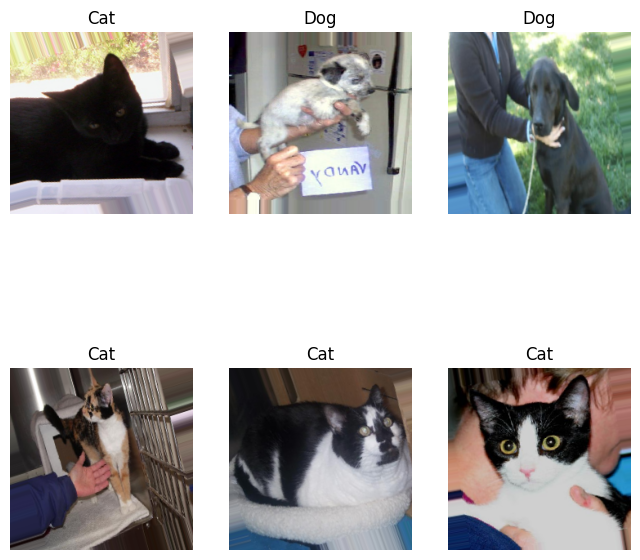

In [5]:
images, labels = next(train_generator)

plt.figure(figsize=(8,8))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title("Dog" if labels[i] == 1 else "Cat")
    plt.axis("off")
plt.show()

## Baseline CNN Model (From Scratch)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [10]:
baseline_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [11]:
baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
baseline_model.summary()

In [ ]:
baseline_model.build((None, 224, 224, 3))
baseline_model.summary()

In [14]:
baseline_model.build((None, 224, 224, 3))
baseline_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,507,269 (127.82 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,338,180 (85.21 MB)

In [15]:
baseline_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,507,269 (127.82 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,338,180 (85.21 MB)

In [16]:
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(test_generator)
print("Baseline Test Accuracy:", baseline_test_acc)

 4/15 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.7650 - loss: 0.6249

UnknownError: Graph execution error:

Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x000001A5E2F32160>
Traceback (most recent call last):

  File "C:\Users\ashifa\Desktop\gpp\cats-dogs-image-classification\venv\lib\site-packages\tensorflow\python\ops\script_ops.py", line 269, in __call__
    ret = func(*args)

  File "C:\Users\ashifa\Desktop\gpp\cats-dogs-image-classification\venv\lib\site-packages\tensorflow\python\autograph\impl\api.py", line 643, in wrapper
    return func(*args, **kwargs)

  File "C:\Users\ashifa\Desktop\gpp\cats-dogs-image-classification\venv\lib\site-packages\tensorflow\python\data\ops\from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))

  File "C:\Users\ashifa\Desktop\gpp\cats-dogs-image-classification\venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py", line 

In [17]:
baseline_history = baseline_model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)

Epoch 1/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.6348 - loss: 0.6442 - val_accuracy: 0.6089 - val_loss: 0.6496
Epoch 2/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.6452 - loss: 0.6411 - val_accuracy: 0.6311 - val_loss: 0.6418
Epoch 3/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.6681 - loss: 0.6216 - val_accuracy: 0.6444 - val_loss: 0.6354
Epoch 4/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.6433 - loss: 0.6322 - val_accuracy: 0.6200 - val_loss: 0.6409
Epoch 5/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.6733 - loss: 0.6103 - val_accuracy: 0.6400 - val_loss: 0.6211


In [18]:
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(test_generator, verbose=1)
print("Baseline Test Accuracy:", baseline_test_acc)

 4/15 ━━━━━━━━━━━━━━━━━━━━ 4s 395ms/step - accuracy: 0.6270 - loss: 0.7374

UnknownError: Graph execution error:

Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x000001A5E34F6390>
Traceback (most recent call last):

  File "C:\Users\ashifa\Desktop\gpp\cats-dogs-image-classification\venv\lib\site-packages\tensorflow\python\ops\script_ops.py", line 269, in __call__
    ret = func(*args)

  File "C:\Users\ashifa\Desktop\gpp\cats-dogs-image-classification\venv\lib\site-packages\tensorflow\python\autograph\impl\api.py", line 643, in wrapper
    return func(*args, **kwargs)

  File "C:\Users\ashifa\Desktop\gpp\cats-dogs-image-classification\venv\lib\site-packages\tensorflow\python\data\ops\from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))

  File "C:\Users\ashifa\Desktop\gpp\cats-dogs-image-classification\venv\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py", line 

In [19]:
from PIL import Image
import os

def remove_corrupted_images(directory):
    removed = 0
    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                img = Image.open(file_path)
                img.verify()
            except Exception:
                os.remove(file_path)
                removed += 1
    print(f"Removed {removed} corrupted images from {directory}")

In [20]:
remove_corrupted_images("data/train")
remove_corrupted_images("data/val")
remove_corrupted_images("data/test")

Removed 0 corrupted images from data/train
Removed 0 corrupted images from data/val
Removed 1 corrupted images from data/test


In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [4]:
train_generator = train_datagen.flow_from_directory(
    "data/train",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_generator = val_test_datagen.flow_from_directory(
    "data/val",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_generator = val_test_datagen.flow_from_directory(
    "data/test",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 2100 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Found 449 images belonging to 2 classes.


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D,
    Dense, Dropout, GlobalAveragePooling2D
)

baseline_model = Sequential([
    Input(shape=(224, 224, 3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [7]:
baseline_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(test_generator, verbose=1)
print("Baseline Test Accuracy:", baseline_test_acc)

15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 400ms/step - accuracy: 0.5011 - loss: 0.6938
Baseline Test Accuracy: 0.5011135935783386


## Transfer Learning using ResNet50 (Feature Extraction)

In [9]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

In [10]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


In [11]:
for layer in base_model.layers:
    layer.trainable = False

In [12]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)
resnet_model = Model(inputs=base_model.input, outputs=output)

In [13]:
resnet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [14]:
resnet_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)  │ (None, 224, 224, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv1_pad (ZeroPadding2D)   │ (None, 230, 230, 3)     │              0 │ input_layer_2[0][0]     │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv1_conv (Conv2D)         │ (None, 112, 112, 64)    │          9,472 │ conv1_pad[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv1_bn                    │ (None, 112, 112, 64)    │            256 │ conv1_conv[0][0]        │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv1_relu (Activation)     │ (None, 112, 112, 64)    │              0 │ conv1_bn[0][0]          │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ pool1_pad (ZeroPadding2D)   │ (None, 114, 114, 64)    │              0 │ conv1_relu[0][0]        │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ pool1_pool (MaxPooling2D)   │ (None, 56, 56, 64)      │              0 │ pool1_pad[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2_block1_1_conv         │ (None, 56, 56, 64)      │          4,160 │ pool1_pool[0][0]        │
│ (Conv2D)                    │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2_block1_1_bn           │ (None, 56, 56, 64)      │            256 │ conv2_block1_1_conv[0]… │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2_block1_1_relu         │ (None, 56, 56, 64)      │              0 │ conv2_block1_1_bn[0][0] │
│ (Activation)                │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2_block1_2_conv         │ (None, 56, 56, 64)      │         36,928 │ conv2_block1_1_relu[0]… │
│ (Conv2D)                    │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2_block1_2_bn           │ (None, 56, 56, 64)      │            256 │ conv2_block1_2_conv[0]… │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2_block1_2_relu         │ (None, 56, 56, 64)      │              0 │ conv2_block1_2_bn[0][0] │
│ (Activation)                │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2_block1_0_conv         │ (None, 56, 56, 256)     │         16,640 │ pool1_pool[0][0]        │
│ (Conv2D)                    │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ conv2_block1_3_conv         │ (None, 56, 56, 256)     │    

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [15]:
history_resnet_phase1 = resnet_model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)

Epoch 1/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 315s 5s/step - accuracy: 0.5233 - loss: 0.7734 - val_accuracy: 0.6356 - val_loss: 0.6651
Epoch 2/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 310s 4s/step - accuracy: 0.5714 - loss: 0.6774 - val_accuracy: 0.5489 - val_loss: 0.6712
Epoch 3/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 306s 4s/step - accuracy: 0.5638 - loss: 0.6749 - val_accuracy: 0.6133 - val_loss: 0.6634
Epoch 4/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 276s 4s/step - accuracy: 0.5800 - loss: 0.6690 - val_accuracy: 0.5889 - val_loss: 0.6652
Epoch 5/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 280s 4s/step - accuracy: 0.5990 - loss: 0.6674 - val_accuracy: 0.5844 - val_loss: 0.6666


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns

In [3]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [5]:
train_generator = train_datagen.flow_from_directory(
    "data/train",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_generator = val_test_datagen.flow_from_directory(
    "data/val",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_generator = val_test_datagen.flow_from_directory(
    "data/test",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 2100 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Found 449 images belonging to 2 classes.


In [6]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

resnet_model = Model(inputs=base_model.input, outputs=output)

resnet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [6]:
history_resnet_phase1 = resnet_model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)

Epoch 1/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 312s 4s/step - accuracy: 0.5305 - loss: 0.7223 - val_accuracy: 0.6000 - val_loss: 0.6710
Epoch 2/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 281s 4s/step - accuracy: 0.5405 - loss: 0.6897 - val_accuracy: 0.6222 - val_loss: 0.6733
Epoch 3/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 282s 4s/step - accuracy: 0.5876 - loss: 0.6743 - val_accuracy: 0.6022 - val_loss: 0.6673
Epoch 4/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 282s 4s/step - accuracy: 0.5810 - loss: 0.6732 - val_accuracy: 0.5844 - val_loss: 0.6661
Epoch 5/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 285s 4s/step - accuracy: 0.5705 - loss: 0.6753 - val_accuracy: 0.6067 - val_loss: 0.6648


In [7]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_resnet_phase2 = resnet_model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)

Epoch 1/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 426s 6s/step - accuracy: 0.5638 - loss: 0.9903 - val_accuracy: 0.5000 - val_loss: 0.7279
Epoch 2/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 381s 6s/step - accuracy: 0.6548 - loss: 0.6218 - val_accuracy: 0.5000 - val_loss: 0.8103
Epoch 3/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 377s 6s/step - accuracy: 0.6743 - loss: 0.5890 - val_accuracy: 0.5000 - val_loss: 0.7084
Epoch 4/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 374s 6s/step - accuracy: 0.7038 - loss: 0.5753 - val_accuracy: 0.7022 - val_loss: 0.6003
Epoch 5/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 385s 6s/step - accuracy: 0.7210 - loss: 0.5497 - val_accuracy: 0.7022 - val_loss: 0.5646


In [8]:
resnet_model.save("resnet50_cats_dogs.h5")

In [9]:
resnet_model.save("resnet50_cats_dogs.keras")

In [10]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [11]:
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [12]:
history_resnet_phase2 = resnet_model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)

Epoch 1/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 395s 6s/step - accuracy: 0.7229 - loss: 0.5484 - val_accuracy: 0.7267 - val_loss: 0.5425
Epoch 2/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 384s 6s/step - accuracy: 0.7405 - loss: 0.5320 - val_accuracy: 0.7200 - val_loss: 0.5292
Epoch 3/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 376s 6s/step - accuracy: 0.7457 - loss: 0.5179 - val_accuracy: 0.7600 - val_loss: 0.5046
Epoch 4/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 383s 6s/step - accuracy: 0.7662 - loss: 0.5023 - val_accuracy: 0.7400 - val_loss: 0.5462
Epoch 5/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 435s 7s/step - accuracy: 0.7648 - loss: 0.4867 - val_accuracy: 0.7533 - val_loss: 0.5058


In [13]:
resnet_test_loss, resnet_test_acc = resnet_model.evaluate(
    test_generator, verbose=1
)

print("ResNet50 Test Accuracy:", resnet_test_acc)

15/15 ━━━━━━━━━━━━━━━━━━━━ 64s 4s/step - accuracy: 0.7082 - loss: 0.5156
ResNet50 Test Accuracy: 0.7082405090332031


In [14]:
import numpy as np
y_true = test_generator.classes
y_pred_probs = resnet_model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int).ravel()

15/15 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step


In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Cat", "Dog"],
    yticklabels=["Cat", "Dog"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ResNet50")
plt.show()

print(classification_report(
    y_true,
    y_pred,
    target_names=["Cat", "Dog"]
))

ModuleNotFoundError: No module named 'seaborn'

In [7]:
resnet_model = tf.keras.models.load_model("resnet50_cats_dogs.keras")

C:\Users\ashifa\Desktop\gpp\cats-dogs-image-classification\venv\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 42 variables whereas the saved optimizer has 82 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns

In [9]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

In [10]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [11]:
train_generator = train_datagen.flow_from_directory(
    "data/train",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_generator = val_test_datagen.flow_from_directory(
    "data/val",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_generator = val_test_datagen.flow_from_directory(
    "data/test",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 2100 images belonging to 2 classes.
Found 450 images belonging to 2 classes.
Found 449 images belonging to 2 classes.


In [12]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

resnet_model = Model(inputs=base_model.input, outputs=output)

In [13]:
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [14]:
resnet_model = tf.keras.models.load_model("resnet50_cats_dogs.keras")

In [15]:
resnet_test_loss, resnet_test_acc = resnet_model.evaluate(
    test_generator, verbose=1
)

print("ResNet50 Test Accuracy:", resnet_test_acc)

15/15 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.7327 - loss: 0.5489
ResNet50 Test Accuracy: 0.7327394485473633


In [16]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = test_generator.classes
y_pred_probs = resnet_model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype(int).ravel()

15/15 ━━━━━━━━━━━━━━━━━━━━ 61s 4s/step


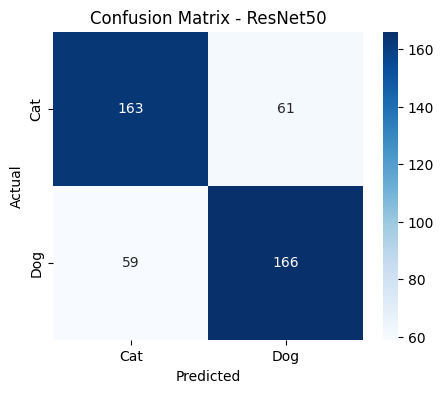

              precision    recall  f1-score   support

         Cat       0.73      0.73      0.73       224
         Dog       0.73      0.74      0.73       225

    accuracy                           0.73       449
   macro avg       0.73      0.73      0.73       449
weighted avg       0.73      0.73      0.73       449



In [17]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Cat", "Dog"],
    yticklabels=["Cat", "Dog"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ResNet50")
plt.show()

print(classification_report(
    y_true,
    y_pred,
    target_names=["Cat", "Dog"]
))

In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

C:\Users\ashifa\Desktop\gpp\cats-dogs-image-classification\venv\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


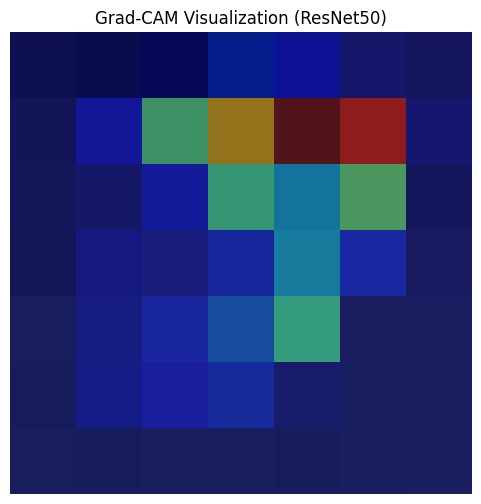

In [19]:
img_batch, label_batch = next(test_generator)

img = img_batch[0]
img_array = np.expand_dims(img, axis=0)

heatmap = make_gradcam_heatmap(
    img_array,
    resnet_model,
    last_conv_layer_name="conv5_block3_out"
)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.imshow(heatmap, cmap="jet", alpha=0.5)
plt.axis("off")
plt.title("Grad-CAM Visualization (ResNet50)")
plt.show()